<a href="https://colab.research.google.com/github/radinelageorgieva/plant-disease-classification/blob/main/Plant_Disease_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Plant Disease Classification using EfficientNet-B0 Transfer learning and explainable AI with Grad-CAM

#Introduction

The primary objective of this project is automated Plant Disease Classification utilizing deep convolutional neural networks (CNNs). The dataset used is Plant Diseases dataset sourced from Kaggle/https://www.kaggle.com/datasets/saroz014/plant-diseases. It contains images of crop leaves categorized into 38 distinct classes: 23 classes representing various plant phytopathologies and 15 classes with healthy plant leaves. The dataset is structured into two main parts: Train folder containing approx. 173,000 images and a test folder containing approx. 43,000 images.
#Methodology Framework:

##1. MLflow Integration
MLOps framework - MLflow is integrated into the experimental setup. MLflow tracking server monitors training metrics in real time. This architecture allows for systematic logging of the loss and accuracy per epoch.

##2. Data preprocessing and Augmentation
Input image transformations were applied to standardize the data and artificially expand the dataset variety. This included resizing to 224 × 224 pixels, random horizontal/vertical flips, and tensor normalization based on ImageNet channel statistics.

##3. Exploratory data analysis (EDA)
This step includes generating a class distribution analysis and visual inspection grids to evaluate data quality, verify image characteristics, and map the exact sample distribution across all 38 categories.

## 4. Class imbalance assessment and sampling strategy
Based on the outcomes of the EDA phase, the workflow integrates a conditional balancing strategy. If a significant class imbalance is detected, a **WeightedRandomSampler** will be configured. This sampler calculates a specific weight for each category so that rare classes receive a higher probability of being selected, while very common classes receive lower weights using the formula:

$$P_i = \frac{1}{\text{count}(\text{class}_i)}$$

This approach is planned to ensure that the model encounters an evenly distributed mix of plant pathologies during training, preventing the network from developing a bias toward majority classes.

##5. Dataset stratification
I split the training folder into two parts using a 90/10 ratio. I get train_data (90% for training) and val_data (10% for validation). I use stratified splitting, which means both parts keep the exact same percentages for all 38 diseases.


##6. Transfer Learning and classifier design
I utilized a pre-trained EfficientNet-B0 backbone. All deep convolutional layers responsible for feature extraction were frozen. The default classifier head was replaced with a custom sequential architecture containing a **Dropout layer (p = 0.2) for regularization** and a **Linear layer** mapping the 1,280 extracted features to the 38 output classes.

##7. Model training and optimization

The model was optimized using the **Adam optimizer** with a **learning rate (lr = 0.0001)**. The optimization criterion is the **Cross-Entropy Loss**, which evaluates the model's performance by measuring the difference between the predicted probability distributions and the true labels:

$$ \text{Loss} = -\sum_{c=1}^{M} y_c \log(p_c) $$

Where $M = 38$ is the total number of plant disease classes. The variable $y_c$ acts as a binary indicator (it equals for the correct disease class, and 0 for all other 37 incorrect classes). The predicted probability $p_c$ for each class is calculated by applying the Softmax function to the model's raw outputs ($z_c$):

$$ p_c = \frac{e^{z_c}}{\sum_{j=1}^{M} e^{z_j}} $$


##8. Evaluation and visualization
* Learning curves (training and validation curves):
Generated dynamically using the **MLflowClient API** to plot Loss vs. Epochs and Accuracy vs. Epochs. These curves demonstrate model convergence and verify the absence of overfitting.
* Normalized confusion matrix: A 38 × 38 heatmap displaying accuracy percentages for each class.

##9. Failure modes analysis
Analysis of the images where the model made wrong predictions. I will plot a gallery of the top mistakes to see exactly why the model got confused.

## 10. Explainable AI (XAI) with Grad-CAM
Apply Gradient-weighted Class Activation Mapping (Grad-CAM) to validate the visual reliability of the network. This technique generates colorful heatmaps over the leaves to show exactly which pixel areas and lesions the model focuses on to make its final decision.

## 11. Final Model test
Evaluate the finalized weights of the trained model against the independent test dataset to obtain the definitive baseline accuracy of the computer vision workflow.

##Conclusion



In [8]:
!pip install mlflow

In [27]:
import mlflow
import torch
import os
from torchvision import datasets,  models, transforms
import numpy as np
import matplotlib.pyplot as plt
import random

##1. MLflow Integration

In [10]:
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
mlflow.set_tracking_uri("file:/content/drive/MyDrive/DeepLearning/ML plant diseases/mlflow_runs")

In [13]:
mlflow.set_experiment("Transfer_learning_plant_disease_classification")

<Experiment: artifact_location=('file:///content/drive/MyDrive/DeepLearning/ML plant '
 'diseases/mlflow_runs/515034867812171804'), creation_time=1782977085987, effective_trace_archival_retention=None, experiment_id='515034867812171804', last_update_time=1782977085987, lifecycle_stage='active', name='Transfer_learning_plant_disease_classification', tags={}, trace_location=None, workspace='default'>

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Data preprocessing and Augmentation

### Dataset loading

In [15]:
!ls "/content/drive/My Drive/DeepLearning/ML plant diseases"

dataset_itr2.zip  mlflow_runs			train_1
dvc-storage	  Plant-Disease-Classification	Untitled0.ipynb


In [16]:
!unzip -q "/content/drive/My Drive/DeepLearning/ML plant diseases/dataset_itr2.zip" -d /content/

In [17]:
!ls /content/

drive  sample_data  test  train


In [18]:
train_dir = '/content/train'
test_dir = '/content/test'

I applied several input image transformations to the training data in order to artificially expand the dataset variety and to prevent overfitting. This includes random cropping and resizing, and random horizontal flips.
The **ToTensor()** function is utilized to convert the raw images into PyTorch tensors. Additionally, for data standardization, I configured the normalization layer using the standard ImageNet channel statistics. The images were normalized with a specific mean of [0.485, 0.456, 0.406] and a standard deviation of [0.229, 0.224, 0.225]. The mathematical formula is:
$$\text{image}=\frac{\text{image}-\text{mean}}{\text{std}}$$
This scaling improves and speeds up neural network training because the input data is centered around a zero value and shares the similar distribution. Also, this scaling matches the exact pixel domain that the pre-trained EfficientNet backbone expects, accelerating model training and convergence.

In [19]:
#data augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [20]:
#loading datasets
full_train_dataset = datasets.ImageFolder(train_dir, transform = data_transforms['train'])
test_dataset = datasets.ImageFolder(test_dir, transform = data_transforms['test'])

##3. Exploratory data analysis

In [23]:
class_names = full_train_dataset.classes

In [24]:
class_counts = np.bincount(full_train_dataset.targets)

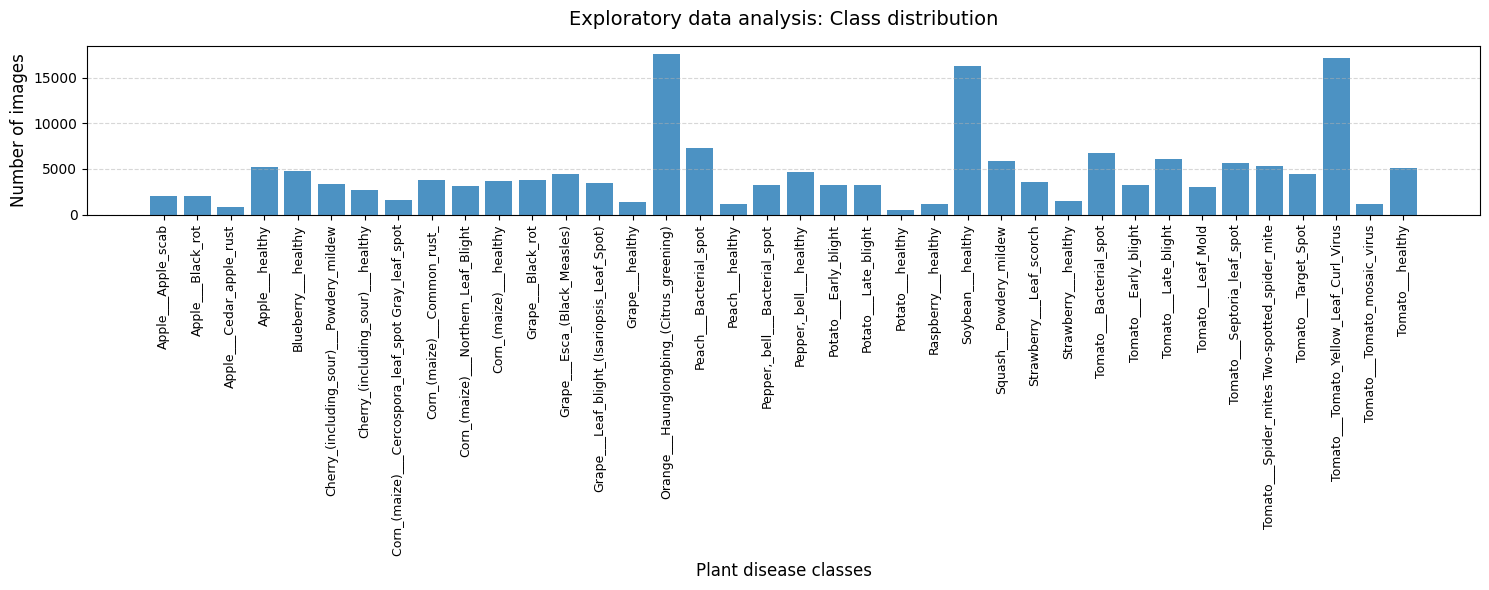

In [25]:
plt.figure(figsize = (15, 6))
plt.bar(class_names, class_counts, alpha = 0.8)
plt.title('Exploratory data analysis: Class distribution', fontsize = 14, pad = 15)
plt.xlabel('Plant disease classes', fontsize = 12)
plt.ylabel('Number of images', fontsize = 12)
plt.xticks(rotation = 90, fontsize = 9)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

The analysis chart reveals a significant class imbalance across the 38 plant categories. The image distribution is highly unbalanced, with some rare diseases containing only 400-500 samples, while dominant categories exceed 17,000 images. Model trainig on such skewed data would cause a severe bias toward the majority classes, leading to low accuracy on rare diseases. To mitigate this issue, I will implement **WeightedRandomSampler** in the training phase. This sampler calculates a specific weight for each category so that rare classes receive a higher probability of being selected, while very common classes receive lower weights, forcing the model to learn from all plant diseases equally.

In [21]:
#Dataset analysis: class distribution
class_counts = {folder: len(os.listdir(os.path.join(train_dir, folder))) for folder in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, folder))}

In [22]:
for class_name, count in sorted(class_counts.items(), key = lambda x: x[1], reverse = True):
    print(f"Class: {class_name:<30} | Count images: {count}")

Class: Orange___Haunglongbing_(Citrus_greening) | Count images: 17624
Class: Tomato___Tomato_Yellow_Leaf_Curl_Virus | Count images: 17144
Class: Soybean___healthy              | Count images: 16288
Class: Peach___Bacterial_spot         | Count images: 7352
Class: Tomato___Bacterial_spot        | Count images: 6808
Class: Tomato___Late_blight           | Count images: 6109
Class: Squash___Powdery_mildew        | Count images: 5872
Class: Tomato___Septoria_leaf_spot    | Count images: 5668
Class: Tomato___Spider_mites Two-spotted_spider_mite | Count images: 5364
Class: Apple___healthy                | Count images: 5264
Class: Tomato___healthy               | Count images: 5089
Class: Blueberry___healthy            | Count images: 4808
Class: Pepper,_bell___healthy         | Count images: 4725
Class: Tomato___Target_Spot           | Count images: 4496
Class: Grape___Esca_(Black_Measles)   | Count images: 4428
Class: Corn_(maize)___Common_rust_    | Count images: 3816
Class: Grape___Black

### Random images

In [28]:
random_indices = random.sample(range(len(full_train_dataset)), 8)

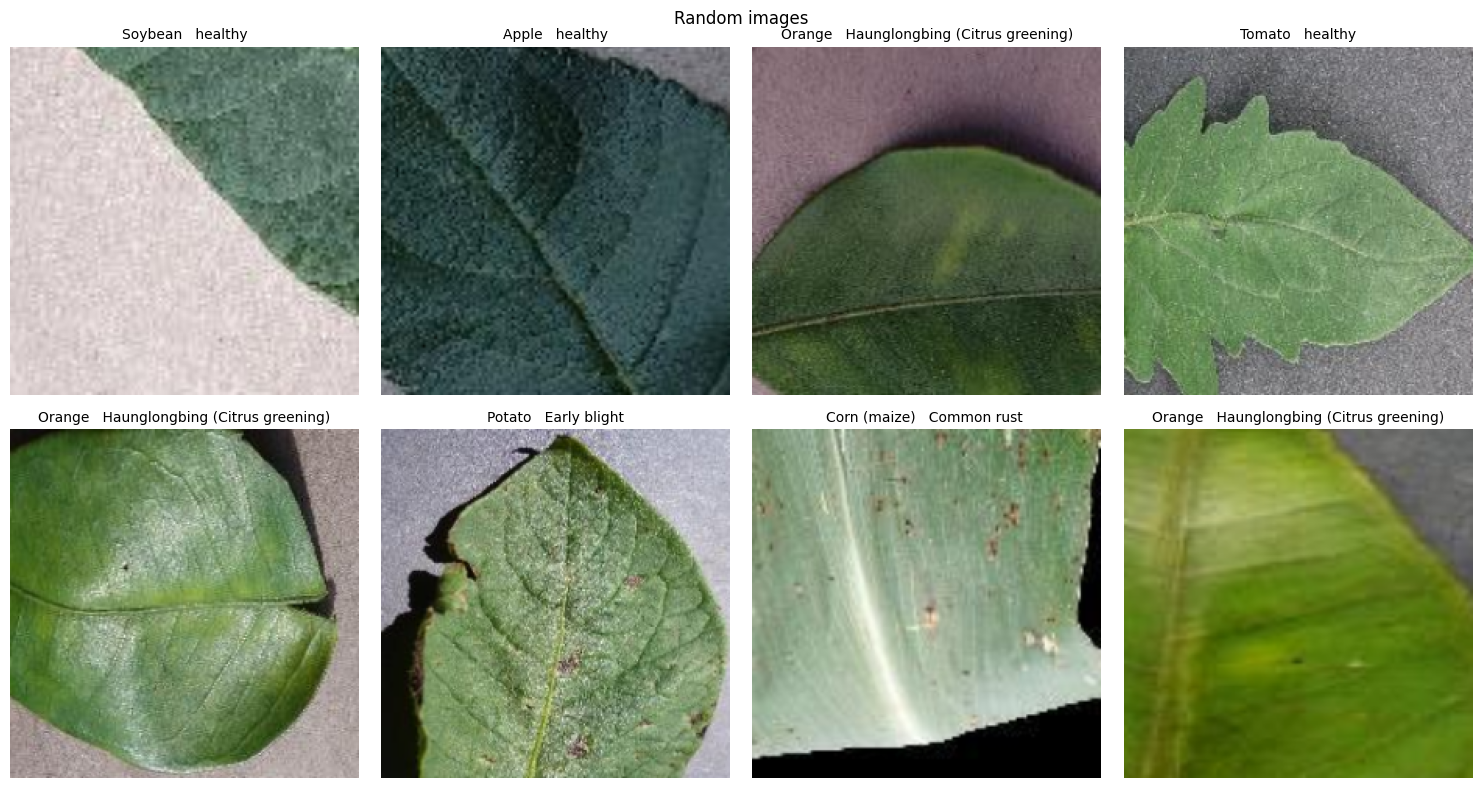

In [41]:
plt.figure(figsize=(15, 8))
for i, idx in enumerate(random_indices):
  image, label = full_train_dataset[idx]
  class_name = full_train_dataset.classes[label]

  #invert ImageNet normalization to restore original pixel range
  img = image.permute(1, 2, 0).numpy()
  img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

  plt.subplot(2, 4, i + 1)
  plt.imshow(img)

  if '___' in class_names:
    parts = class_name.split('___')
    plant = parts[0].replace('_', ' ')
    condition = parts[1].replace('_', ' ')
    display_title = f"{plant}\n({condition})"
  else:
        display_title = class_name.replace('_', ' ')
  plt.title(display_title, fontsize = 10)
  plt.axis('off')

plt.suptitle("Random images")
plt.tight_layout(h_pad=3.0)
plt.show()